# 03 · Model dự đoán rủi ro thanh toán lỗi

**Mục tiêu:** trước khi khách bấm thanh toán, ước lượng xác suất giao dịch bị lỗi → với giao dịch rủi ro cao, gợi ý phương thức an toàn hơn (ví trong app) hoặc hướng dẫn trước.

**Nguyên tắc:**
- Chỉ dùng thông tin **có tại thời điểm thanh toán** (lịch sử *trước* giao dịch đó) → tránh data leakage.
- Chia **theo thời gian**: train 2019–2021, test 2022 — mô phỏng đúng cách model được dùng thật.
- So với **baseline đơn giản** trước khi kết luận model có giá trị.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))  # để import được thư mục src/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

pd.set_option("display.max_columns", None)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
BLUE, RED, GREY = "#2f6db5", "#d1495b", "#9aa5b1"

In [2]:
import os
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")
from sklearn.metrics import roc_auc_score
from src.data_prep import load_tickets
from src import model as fm

df = load_tickets()
X = fm.build_features(df)
train_df, test_df = fm.time_split(X)
print(f"Train: {len(train_df):,} (tỷ lệ lỗi {train_df['is_failed'].mean():.1%}) | Test 2022: {len(test_df):,} (tỷ lệ lỗi {test_df['is_failed'].mean():.1%})")
print("Features:", fm.FEATURES)

Train: 59,991 (tỷ lệ lỗi 16.7%) | Test 2022: 94,734 (tỷ lệ lỗi 11.6%)
Features: ['paying_method', 'platform', 'os_version', 'campaign_type', 'usergender', 'hour', 'dow', 'original_price', 'discount_rate', 'birth_year', 'n_prev_attempts', 'n_prev_failed', 'n_prev_success', 'last_attempt_failed', 'minutes_since_prev']


## 1. Train & so với baseline
Baseline = tỷ lệ lỗi lịch sử của **phương thức thanh toán** (một biến duy nhất).
`capture@20%`: nếu chỉ can thiệp 20% giao dịch rủi ro nhất thì bắt được bao nhiêu % ca lỗi (chọn ngẫu nhiên thì = 20%).

In [3]:
lgbm = fm.train(train_df)
results = fm.evaluate(lgbm, train_df, test_df)
results.style.format("{:.3f}")

,AUC,capture@10%,capture@20%,capture@30%
model,,,,
Rule: paying_method,0.750,0.233,0.415,0.574
LightGBM,0.766,0.239,0.432,0.608


**Đọc kết quả một cách trung thực:**
- LightGBM tốt hơn ngẫu nhiên rõ rệt: nhắm 20% giao dịch rủi ro nhất bắt được **~43% ca lỗi** (≈2.2 lần so với chọn ngẫu nhiên).
- Nhưng LightGBM **chỉ nhỉnh hơn một chút** so với baseline một biến (AUC ~0.77 vs ~0.75; capture@20% ~43% vs ~42%) → **phần lớn tín hiệu nằm ở phương thức thanh toán**. Hệ quả kinh doanh: đòn bẩy lớn nhất không phải "model phức tạp" mà là **khuyến khích khách dùng phương thức ít lỗi**.
- Model vẫn có ích ở chỗ xếp hạng chi tiết hơn *bên trong* từng phương thức (giờ, giá vé, lịch sử lỗi của khách…).

## 2. Model đang dựa vào đâu? (SHAP)

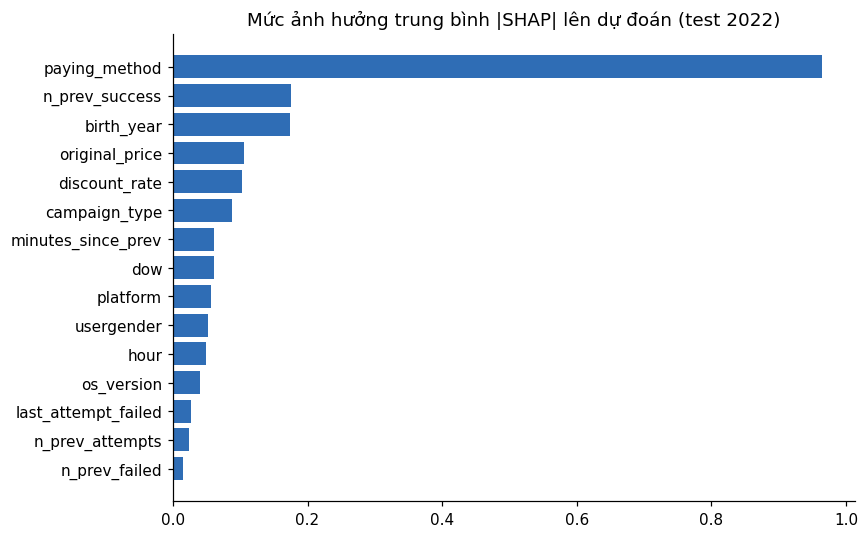

In [4]:
contrib = fm.explain(lgbm, test_df)
importance = contrib.abs().mean().sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importance.index, importance, color=BLUE)
ax.set_title("Mức ảnh hưởng trung bình |SHAP| lên dự đoán (test 2022)")
plt.tight_layout()

## 3. Tỷ lệ lỗi thực tế theo nhóm rủi ro

,predicted,actual,tickets
risk_decile,,,
1,0.017,0.009,9474
2,0.030,0.015,9473
3,0.038,0.019,9473
4,0.048,0.023,9474
5,0.073,0.053,9473
6,0.128,0.149,9473
7,0.176,0.190,9474
8,0.219,0.205,9473
9,0.269,0.224,9473


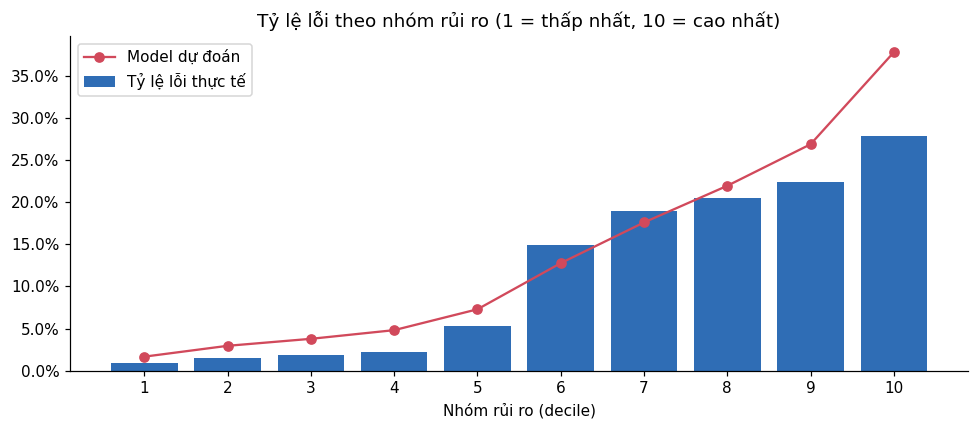

In [5]:
test_scored = test_df.assign(risk=lgbm.predict_proba(test_df[fm.FEATURES])[:, 1])
test_scored["risk_decile"] = pd.qcut(test_scored["risk"].rank(method="first"), 10, labels=range(1, 11))
deciles = test_scored.groupby("risk_decile", observed=True).agg(
    predicted=("risk", "mean"), actual=("is_failed", "mean"), tickets=("ticket_id", "count"))
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(deciles.index.astype(str), deciles["actual"], color=BLUE, label="Tỷ lệ lỗi thực tế")
ax.plot(deciles.index.astype(str), deciles["predicted"], color=RED, marker="o", label="Model dự đoán")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
ax.set(title="Tỷ lệ lỗi theo nhóm rủi ro (1 = thấp nhất, 10 = cao nhất)", xlabel="Nhóm rủi ro (decile)")
ax.legend()
plt.tight_layout()
deciles.round(3)

Thứ tự xếp hạng tốt (nhóm 10 lỗi nhiều gấp ~30 lần nhóm 1), nhưng model **dự đoán cao hơn thực tế** ở các nhóm rủi ro cao — vì tỷ lệ lỗi giai đoạn train (16.7%) cao hơn năm 2022 (11.6%). Nếu dùng *xác suất* (không chỉ thứ hạng) để ra quyết định thì cần hiệu chỉnh lại (calibration) trên dữ liệu gần nhất.

## 4. Những gì ĐÃ THỬ nhưng KHÔNG hiệu quả
Ghi lại kết quả âm cũng quan trọng như kết quả dương — nó cho biết **không nên đầu tư vào đâu**.

**(a) Dự đoán khách mua lại trong 90 ngày sau lần mua đầu** (để Marketing chọn khách nên chăm sóc):

In [6]:
s = X[X["is_failed"] == 0].copy()
s["k"] = s.groupby("customer_id").cumcount()
first_buy = s[s["k"] == 0].merge(
    s[s["k"] == 1][["customer_id", "time"]].rename(columns={"time": "t2"}), on="customer_id", how="left")
first_buy["repeat_90d"] = ((first_buy["t2"] - first_buy["time"]).dt.days <= 90).astype(int)
first_buy = first_buy[first_buy["time"] < "2022-10-01"]  # cần đủ 90 ngày quan sát
first_buy["had_failed_before"] = (first_buy["n_prev_failed"] > 0).astype(int)
F_REPEAT = fm.CATEGORICAL + ["hour", "dow", "original_price", "discount_rate", "birth_year", "had_failed_before"]
tr, te = first_buy[first_buy["time"] < "2022-01-01"], first_buy[first_buy["time"] >= "2022-01-01"]
import lightgbm as lgb
m_repeat = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, random_state=42, verbose=-1).fit(tr[F_REPEAT], tr["repeat_90d"])
print(f"Tỷ lệ mua lại 90 ngày: {te['repeat_90d'].mean():.1%} | AUC = {roc_auc_score(te['repeat_90d'], m_repeat.predict_proba(te[F_REPEAT])[:, 1]):.3f}")

Tỷ lệ mua lại 90 ngày: 8.7% | AUC = 0.525


AUC ≈ 0.5 = **không tốt hơn đoán ngẫu nhiên**. Thông tin lúc mua vé đầu (kênh, khuyến mãi, giờ, giá…) không cho biết khách có quay lại không → khớp với phát hiện ở notebook 01: khuyến mãi không làm khách quay lại nhiều hơn. Muốn dự đoán được cần dữ liệu hành vi khác (xem phim gì, đánh giá, tương tác app…).

**(b) Dự đoán giao dịch lỗi nào sẽ được khách tự mua lại trong 7 ngày** (để CSKH ưu tiên):

In [7]:
failed = X[X["is_failed"] == 1].sort_values("time")
succ = X.loc[X["is_failed"] == 0, ["customer_id", "time"]].rename(columns={"time": "next_ok"}).sort_values("next_ok")
failed = pd.merge_asof(failed, succ, left_on="time", right_on="next_ok", by="customer_id", direction="forward")
failed["recovered_7d"] = ((failed["next_ok"] - failed["time"]) <= pd.Timedelta(days=7)).astype(int)
failed = failed[failed["time"] < "2022-12-24"]
failed["status_id"] = failed["status_id"].astype("category")
F_REC = fm.FEATURES + ["status_id"]
tr, te = failed[failed["time"] < "2022-01-01"], failed[failed["time"] >= "2022-01-01"]
m_rec = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=15, min_child_samples=50,
                           random_state=42, verbose=-1).fit(tr[F_REC], tr["recovered_7d"])
print(f"Tỷ lệ tự mua lại: {te['recovered_7d'].mean():.1%} | AUC = {roc_auc_score(te['recovered_7d'], m_rec.predict_proba(te[F_REC])[:, 1]):.3f}")

Tỷ lệ tự mua lại: 7.2% | AUC = 0.518


Cũng ≈ ngẫu nhiên, và chỉ ~7% giao dịch lỗi được tự mua lại. **Kết luận:** không cần model để chọn ai cần cứu — **liên hệ lại toàn bộ khách bị lỗi** (rẻ, đơn giản, tự động hóa được) là phương án hợp lý hơn. Đây là lý do pipeline ở notebook 04 tạo danh sách cứu đơn cho *tất cả* giao dịch lỗi chưa được mua lại.

## 5. Lưu model & đề xuất triển khai

In [8]:
fm.save(lgbm)
print("Đã lưu:", fm.MODEL_PATH.relative_to(fm.MODEL_PATH.parents[1]))

Đã lưu:

 models\payment_failure_lgbm.txt


**Cách dùng đề xuất:** tại màn hình checkout, nếu điểm rủi ro thuộc top 20% → hiển thị gợi ý *"Thanh toán bằng Ví trong app để giảm rủi ro lỗi"*.

⚠️ **Model chỉ cho thấy tương quan.** Chưa chắc khách đổi sang ví thì sẽ hết lỗi (có thể khách dùng ví vốn đã khác khách dùng thẻ). Trước khi triển khai rộng cần **A/B test**:
- Nhóm A: checkout như cũ · Nhóm B: hiện gợi ý cho giao dịch rủi ro cao
- Chỉ số chính: tỷ lệ thanh toán thành công · Chỉ số phụ: tỷ lệ bỏ giỏ, tỷ lệ chọn ví
- Thời gian: tối thiểu 2–4 tuần để đủ mẫu và qua nhiều ngày trong tuần.